In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import cmocean
from mpl_toolkits.basemap import Basemap
from matplotlib import colors
from scipy.stats import linregress
import pandas as pd
import xarray as xr

# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated) from Satellite Observations (Near Real Time)
file_id = Dataset('../../data/chl/chl_1999_2024_day_aloha_l3_2.nc')
chl = file_id.variables["CHL"][:]
time = file_id.variables["time"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector
chl_time = pd.to_datetime(date_vector)

# Target coordinates
target_lat = 22.75
target_lon = -158.0

# Find nearest indices
lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

# 3x3 box (±1 pixel around center)
lat_slice = slice(lat_idx - 1, lat_idx + 2)
lon_slice = slice(lon_idx - 1, lon_idx + 2)

chl_crop = chl[:, lat_slice, lon_slice]
lat_crop = lat[lat_slice]
lon_crop = lon[lon_slice]

# Filter to <= 2022-12-30
time_mask = chl_time <= '2022-12-30'

chl_crop = chl_crop[time_mask, :, :]
chl_time = chl_time[time_mask]

print(f"Time range: {chl_time[0].date()} to {chl_time[-1].date()}")
print(f"Cropped shape: {chl_crop.shape}")
print(f"Nearest lat: {lat[lat_idx]:.4f}, Nearest lon: {lon[lon_idx]:.4f}")
print(f"Lat window: {lat_crop}")
print(f"Lon window: {lon_crop}")
print(f"Cropped shape: {chl_crop.shape}")

# Build an xarray DataArray with the time coordinate
chl_xa = xr.DataArray(
    chl_crop,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': chl_time,
        'lat': lat_crop,
        'lon': lon_crop
    }
)

# Compute median climatology for each day of year (1–366)
# chl_clim = chl_xa.groupby('time.dayofyear').median(dim='time')
chl_clim = chl_xa.groupby('time.month').median(dim='time', skipna=True)
chl_anom = chl_xa.groupby('time.month') - chl_clim

print(f"Climatology shape: {chl_clim.shape}")
print(f"Anomaly shape: {chl_anom.shape}")
print(f"Anomaly mean (should be near zero): {float(chl_anom.mean()):.6f}")

# Flatten spatial dims and build a DataFrame
chl_flat = chl_anom.values.reshape(len(chl_time), -1)
df = pd.DataFrame(chl_flat, index=chl_time)
df['month'] = df.index.month

# Melt to long format for boxplot
df_melt = df.melt(id_vars='month', var_name='pixel', value_name='chl_anom')

# --- Raw DataFrame ---
chl_flat_raw = chl_xa.values.reshape(len(chl_time), -1)
df_raw = pd.DataFrame(chl_flat_raw, index=chl_time)
df_raw['month'] = df_raw.index.month
df_melt_raw = df_raw.melt(id_vars='month', var_name='pixel', value_name='chl')

Time range: 1999-01-01 to 2022-12-30
Cropped shape: (8765, 3, 3)
Nearest lat: 22.7708, Nearest lon: -158.0208
Lat window: [22.729164 22.770832 22.812498]
Lon window: [-158.0625  -158.02083 -157.97917]
Cropped shape: (8765, 3, 3)


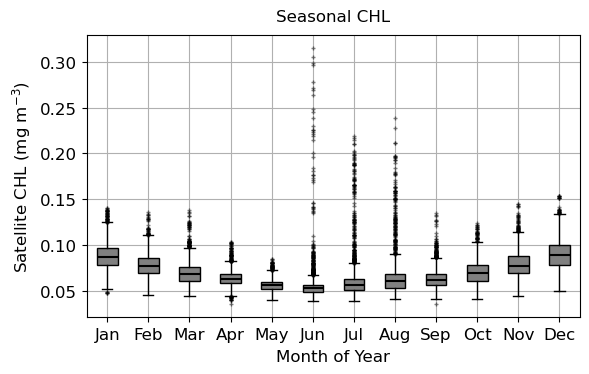

In [ ]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# --- Figure 1: Raw monthly CHL ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
df_melt_raw.boxplot(column='chl', by='month', ax=ax1,
                    showfliers=True, patch_artist=True,
                    boxprops=dict(facecolor='grey', edgecolor='black'),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='+', markeredgecolor='black',
                                  markerfacecolor='black', markersize=3, alpha=0.5))

ax1.set_xlabel('Month of Year', fontsize=12, fontweight='normal', labelpad=5)
ax1.set_ylabel('Satellite CHL (mg m$^{-3}$)', fontsize=12, fontweight='normal', labelpad=5)
ax1.set_title('Seasonal CHL', fontsize=12, pad=10)
fig1.suptitle('')
ax1.set_xticklabels(month_labels, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

plt.tight_layout()
# fig1.savefig('../../figures/chl_raw_boxplot_20260313.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

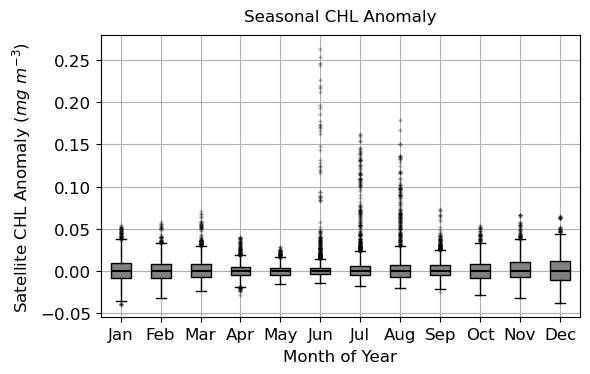

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
df_melt.boxplot(column='chl_anom', by='month', ax=ax, #grid = False,
                showfliers=True, patch_artist=True,
                boxprops=dict(facecolor='grey', edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='+', markeredgecolor='black',
                                  markerfacecolor='black', markersize=3, alpha=0.3))

ax.set_xlabel('Month of Year', fontsize=12, fontweight='normal', labelpad=5)
ax.set_ylabel('Satellite CHL Anomaly ($mg$ $m^{-3}$)', fontsize=12, fontweight='normal', labelpad=5)
ax.set_title('Seasonal CHL Anomaly', fontsize=12, pad=10)
ax.set_ylim(-0.055, 0.28)
fig.suptitle('')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticklabels(month_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig.savefig('../../figures/20260313_seasonal_chl_anomaly_boxplot.pdf', dpi=600, bbox_inches='tight')
plt.show()

Time range: 1999-01-01 to 2022-12-30
Cropped shape: (8765, 3, 3)
Climatology shape: (12, 3, 3)
Anomaly shape: (8765, 3, 3)
Anomaly mean (should be near zero): 0.001663
Trend range: -0.0025 to 0.0086
Detrended range: -0.0431 to 0.2574


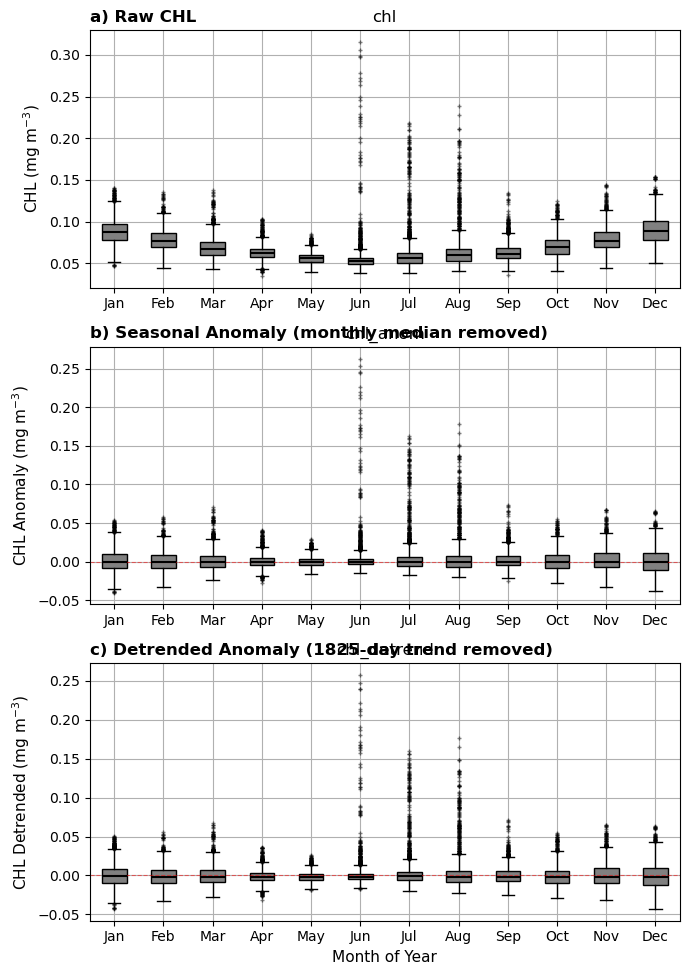

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from netCDF4 import Dataset
from scipy.stats import linregress
from scipy.ndimage import uniform_filter1d
import pandas as pd

# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated)
file_id = Dataset('../../data/chl/chl_1999_2024_day_aloha_l3_2.nc')
chl = file_id.variables["CHL"][:].filled(np.nan).astype('float64')
time = file_id.variables["time"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector
chl_time = pd.to_datetime(date_vector)

# Target coordinates
target_lat = 22.75
target_lon = -158.0

# Find nearest indices
lat_idx = np.argmin(np.abs(lat - target_lat))
lon_idx = np.argmin(np.abs(lon - target_lon))

# 3x3 box (±1 pixel around center)
lat_slice = slice(lat_idx - 1, lat_idx + 2)
lon_slice = slice(lon_idx - 1, lon_idx + 2)

chl_crop = chl[:, lat_slice, lon_slice]
lat_crop = lat[lat_slice]
lon_crop = lon[lon_slice]

# Filter to <= 2022-12-30
time_mask = chl_time <= '2022-12-30'
chl_crop = chl_crop[time_mask, :, :]
chl_time = chl_time[time_mask]

print(f"Time range: {chl_time[0].date()} to {chl_time[-1].date()}")
print(f"Cropped shape: {chl_crop.shape}")

# Build an xarray DataArray with the time coordinate
chl_xa = xr.DataArray(
    chl_crop,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': chl_time,
        'lat': lat_crop,
        'lon': lon_crop
    }
)

# ============================================================================
# Step 1: Remove seasonal cycle (monthly median climatology)
# ============================================================================
chl_clim = chl_xa.groupby('time.month').median(dim='time', skipna=True)
chl_anom = chl_xa.groupby('time.month') - chl_clim

print(f"Climatology shape: {chl_clim.shape}")
print(f"Anomaly shape: {chl_anom.shape}")
print(f"Anomaly mean (should be near zero): {float(chl_anom.mean()):.6f}")

# ============================================================================
# Step 2: Remove long-term trend (365-day running mean)
# ============================================================================
window = 1825
anom_vals = chl_anom.values.copy()

# Replace NaN with 0 for filtering, track valid counts
anom_filled = np.where(np.isnan(anom_vals), 0, anom_vals)
valid_count = np.where(np.isnan(anom_vals), 0, 1).astype('float64')

# Running mean along time axis
trend = uniform_filter1d(anom_filled, size=window, axis=0, mode='reflect')
count = uniform_filter1d(valid_count, size=window, axis=0, mode='reflect')

count[count == 0] = np.nan
trend = trend / count

# Subtract long-term trend
anom_detrended = anom_vals - trend
anom_detrended[np.isnan(anom_vals)] = np.nan

print(f"Trend range: {np.nanmin(trend):.4f} to {np.nanmax(trend):.4f}")
print(f"Detrended range: {np.nanmin(anom_detrended):.4f} to {np.nanmax(anom_detrended):.4f}")

# Build xarray for detrended
chl_detrended = xr.DataArray(
    anom_detrended,
    dims=['time', 'lat', 'lon'],
    coords={
        'time': chl_time,
        'lat': lat_crop,
        'lon': lon_crop
    }
)

# ============================================================================
# Build DataFrames for boxplots
# ============================================================================

# --- Raw CHL ---
chl_flat_raw = chl_xa.values.reshape(len(chl_time), -1)
df_raw = pd.DataFrame(chl_flat_raw, index=chl_time)
df_raw['month'] = df_raw.index.month
df_melt_raw = df_raw.melt(id_vars='month', var_name='pixel', value_name='chl')

# --- Seasonal anomaly (before detrending) ---
chl_flat_anom = chl_anom.values.reshape(len(chl_time), -1)
df_anom = pd.DataFrame(chl_flat_anom, index=chl_time)
df_anom['month'] = df_anom.index.month
df_melt_anom = df_anom.melt(id_vars='month', var_name='pixel', value_name='chl_anom')

# --- Detrended anomaly ---
chl_flat_detrend = anom_detrended.reshape(len(chl_time), -1)
df_detrend = pd.DataFrame(chl_flat_detrend, index=chl_time)
df_detrend['month'] = df_detrend.index.month
df_melt_detrend = df_detrend.melt(id_vars='month', var_name='pixel', value_name='chl_detrend')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ============================================================================
# Plot: 3 panels — Raw, Seasonal Anomaly, Detrended Anomaly
# ============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 10))

# --- Panel 1: Raw CHL ---
df_melt_raw.boxplot(column='chl', by='month', ax=ax1,
                    showfliers=True, patch_artist=True,
                    boxprops=dict(facecolor='grey', edgecolor='black'),
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='+', markeredgecolor='black',
                                   markerfacecolor='black', markersize=3, alpha=0.5))
ax1.set_xlabel('')
ax1.set_ylabel('CHL (mg m$^{-3}$)', fontsize=11)
ax1.set_title('a) Raw CHL', fontsize=12, loc='left', fontweight='bold')
fig.suptitle('')
ax1.set_xticklabels(month_labels, fontsize=10)

# --- Panel 2: Seasonal anomaly ---
df_melt_anom.boxplot(column='chl_anom', by='month', ax=ax2,
                     showfliers=True, patch_artist=True,
                     boxprops=dict(facecolor='grey', edgecolor='black'),
                     medianprops=dict(color='black', linewidth=1.5),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='+', markeredgecolor='black',
                                    markerfacecolor='black', markersize=3, alpha=0.5))
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('')
ax2.set_ylabel('CHL Anomaly (mg m$^{-3}$)', fontsize=11)
ax2.set_title('b) Seasonal Anomaly (monthly median removed)', fontsize=12, loc='left', fontweight='bold')
fig.suptitle('')
ax2.set_xticklabels(month_labels, fontsize=10)

# --- Panel 3: Detrended anomaly ---
df_melt_detrend.boxplot(column='chl_detrend', by='month', ax=ax3,
                        showfliers=True, patch_artist=True,
                        boxprops=dict(facecolor='grey', edgecolor='black'),
                        medianprops=dict(color='black', linewidth=1.5),
                        whiskerprops=dict(color='black'),
                        capprops=dict(color='black'),
                        flierprops=dict(marker='+', markeredgecolor='black',
                                        markerfacecolor='black', markersize=3, alpha=0.5))
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax3.set_xlabel('Month of Year', fontsize=11)
ax3.set_ylabel('CHL Detrended (mg m$^{-3}$)', fontsize=11)
ax3.set_title(f'c) Detrended Anomaly ({window}-day trend removed)', fontsize=12, loc='left', fontweight='bold')
fig.suptitle('')
ax3.set_xticklabels(month_labels, fontsize=10)

plt.tight_layout()
#fig.savefig('../../figures/chl_boxplot_3panel_20260313.pdf', dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig('../../figures/chl_boxplot_3panel_20260313.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

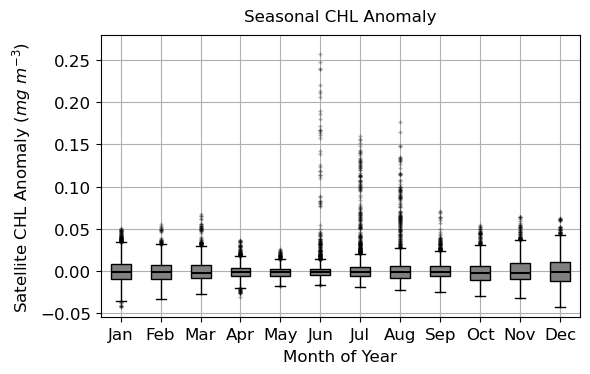

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
df_melt_detrend.boxplot(column='chl_detrend', by='month', ax=ax, #grid = False,
                showfliers=True, patch_artist=True,
                boxprops=dict(facecolor='grey', edgecolor='black'),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='+', markeredgecolor='black',
                                  markerfacecolor='black', markersize=3, alpha=0.3))

ax.set_xlabel('Month of Year', fontsize=12, fontweight='normal', labelpad=5)
ax.set_ylabel('Satellite CHL Anomaly ($mg$ $m^{-3}$)', fontsize=12, fontweight='normal', labelpad=5)
ax.set_title('Seasonal CHL Anomaly', fontsize=12, pad=10)
ax.set_ylim(-0.055, 0.28)
fig.suptitle('')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticklabels(month_labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
fig.savefig('../../figures/20260422_detrended_chl_anomaly_boxplot.pdf', dpi=600, bbox_inches='tight')
plt.show()